# Финальный проект ПАДвЭФ 2026 — Olist (Brazilian E-Commerce)

In [ ]:
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from tqdm.auto import tqdm

pd.set_option('display.expand_frame_repr', False)
%config InlineBackend.figure_format = 'retina'
plt.rcParams['figure.figsize'] = 8, 5
plt.rcParams['axes.grid'] = True
plt.rcParams['font.size'] = 12
plt.rcParams['savefig.format'] = 'pdf'
sns.set_style('darkgrid')
rng = np.random.default_rng(42)
alpha = 0.05
power = 0.80

## Загрузка данных с Kaggle

In [ ]:
import kagglehub
data = kagglehub.dataset_download("olistbr/brazilian-ecommerce")
print("Данные:", data)

Using Colab cache for faster access to the 'brazilian-ecommerce' dataset.
Данные: /kaggle/input/brazilian-ecommerce


## Сборка таблицы заказов

In [ ]:
orders = pd.read_csv(f"{data}/olist_orders_dataset.csv", parse_dates=['order_purchase_timestamp','order_delivered_customer_date',
                                                                      'order_estimated_delivery_date'])
items = pd.read_csv(f"{data}/olist_order_items_dataset.csv")
payments = pd.read_csv(f"{data}/olist_order_payments_dataset.csv")
reviews = pd.read_csv(f"{data}/olist_order_reviews_dataset.csv")
customers = pd.read_csv(f"{data}/olist_customers_dataset.csv")
products = pd.read_csv(f"{data}/olist_products_dataset.csv")
cat_transl = pd.read_csv(f"{data}/product_category_name_translation.csv")

items_agg = items.groupby('order_id').agg(
    item_value=('price','sum'), #сумма цен товаров в заказе
    freight_total=('freight_value','sum'), #сумма стоимостей доставок товаров в заказе
    items_per_order=('order_item_id','count')).reset_index()
payments_agg = payments.groupby('order_id').agg(
    order_value=('payment_value','sum')).reset_index() #сколько клиент реально заплатил(cюда входит доставка): item_value + freight_total
reviews_agg = reviews.groupby('order_id')['review_score'].mean().round().reset_index()

#категория заказа = категория самой дорогой позиции + добавляем перевод на англ.
items_cat = items.merge(products[['product_id','product_category_name']].drop_duplicates('product_id'), on='product_id', how='left')
main_cat = (items_cat.loc[items_cat.groupby('order_id')['price'].idxmax(),['order_id','product_category_name']]
            .merge(cat_transl, on='product_category_name', how='left')
            .reset_index(drop=True))

#способ оплаты заказа = способ с наибольшей суммой платежа
main_pay = (payments.loc[payments.groupby('order_id')['payment_value'].idxmax(),['order_id','payment_type']]
            .reset_index(drop=True))

df = (orders.merge(items_agg, on='order_id', how='left')
            .merge(payments_agg, on='order_id', how='left')
            .merge(main_pay, on='order_id', how='left')
            .merge(reviews_agg, on='order_id', how='left')
            .merge(customers[['customer_id','customer_unique_id','customer_state']], on='customer_id', how='left')
            .merge(main_cat, on='order_id', how='left'))

df = df[['order_id','order_status',
         'order_purchase_timestamp','order_delivered_customer_date','order_estimated_delivery_date',
         'item_value','freight_total','items_per_order',
         'order_value','payment_type','review_score',
         'customer_unique_id','customer_state',
         'product_category_name','product_category_name_english']]

print('orders:', len(df)); df.head(3)

orders: 99441


,order_id,order_status,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,item_value,freight_total,items_per_order,order_value,payment_type,review_score,customer_unique_id,customer_state,product_category_name,product_category_name_english
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,29.99,8.72,1.0,38.71,voucher,4.0,7c396fd4830fd04220f754e42b4e5bff,SP,utilidades_domesticas,housewares
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13,118.70,22.76,1.0,141.46,boleto,4.0,af07308b275d755c9edb36a90c618231,BA,perfumaria,perfumery
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04,159.90,19.22,1.0,179.12,credit_card,5.0,3a653a41f6f9fc3d2a113cf8398680e8,GO,automotivo,auto


## Производные признаки

In [ ]:
df['delivery_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days
df['on_time_flag']  = np.where(df['order_delivered_customer_date'].notna(),
                               df['order_delivered_customer_date'] <= df['order_estimated_delivery_date'], np.nan)
df['freight_ratio'] = df['freight_total'] / df['order_value'].replace(0, np.nan)
df['is_canceled'] = df['order_status'].isin(['canceled','unavailable']).astype(int)
df['review_good'] = (df['review_score'] >= 4).astype('Int64')
df['order_month'] = df['order_purchase_timestamp'].dt.to_period('M').dt.to_timestamp() # дата, обрезанная до начала месяца
df['order_date'] = df['order_purchase_timestamp'].dt.normalize() #дата без времени

## Описание организации и EDA

**Организация:** Olist — бразильский e-commerce-интегратор: подключает малых и средних продавцов к крупным площадкам и берёт на себя витрину, приём платежей и логистику. В датасете — поток заказов маркетплейса за сентябрь 2016 – октябрь 2018 (99 441 заказ).

**Контекст рынка:** 2017–2018 год — фаза быстрого роста рынка e-commerce Бразилии. Спрос сильно сконцентрирован в Сан-Паулу и юго-восточных штатах. Характерная особенность страны — оплата в рассрочку (parcelamento) и болето (бразильский аналог квитанции для оплаты без банковского счета).

**Площадки-партнёры (каналы продаж):** Mercado Livre, B2W (Americanas), Magazine Luiza, Amazon Brasil, Shopee — Olist выставляет на них товары своих продавцов.

**Конкуренты:** Linx, Nuvemshop, VTEX.

**Аудитория / типы клиентов:** Преимущественно розничные B2C-покупатели. Ядро — Сан-Паулу (42% заказов). Покупки в основном разовые и одно-позиционные.

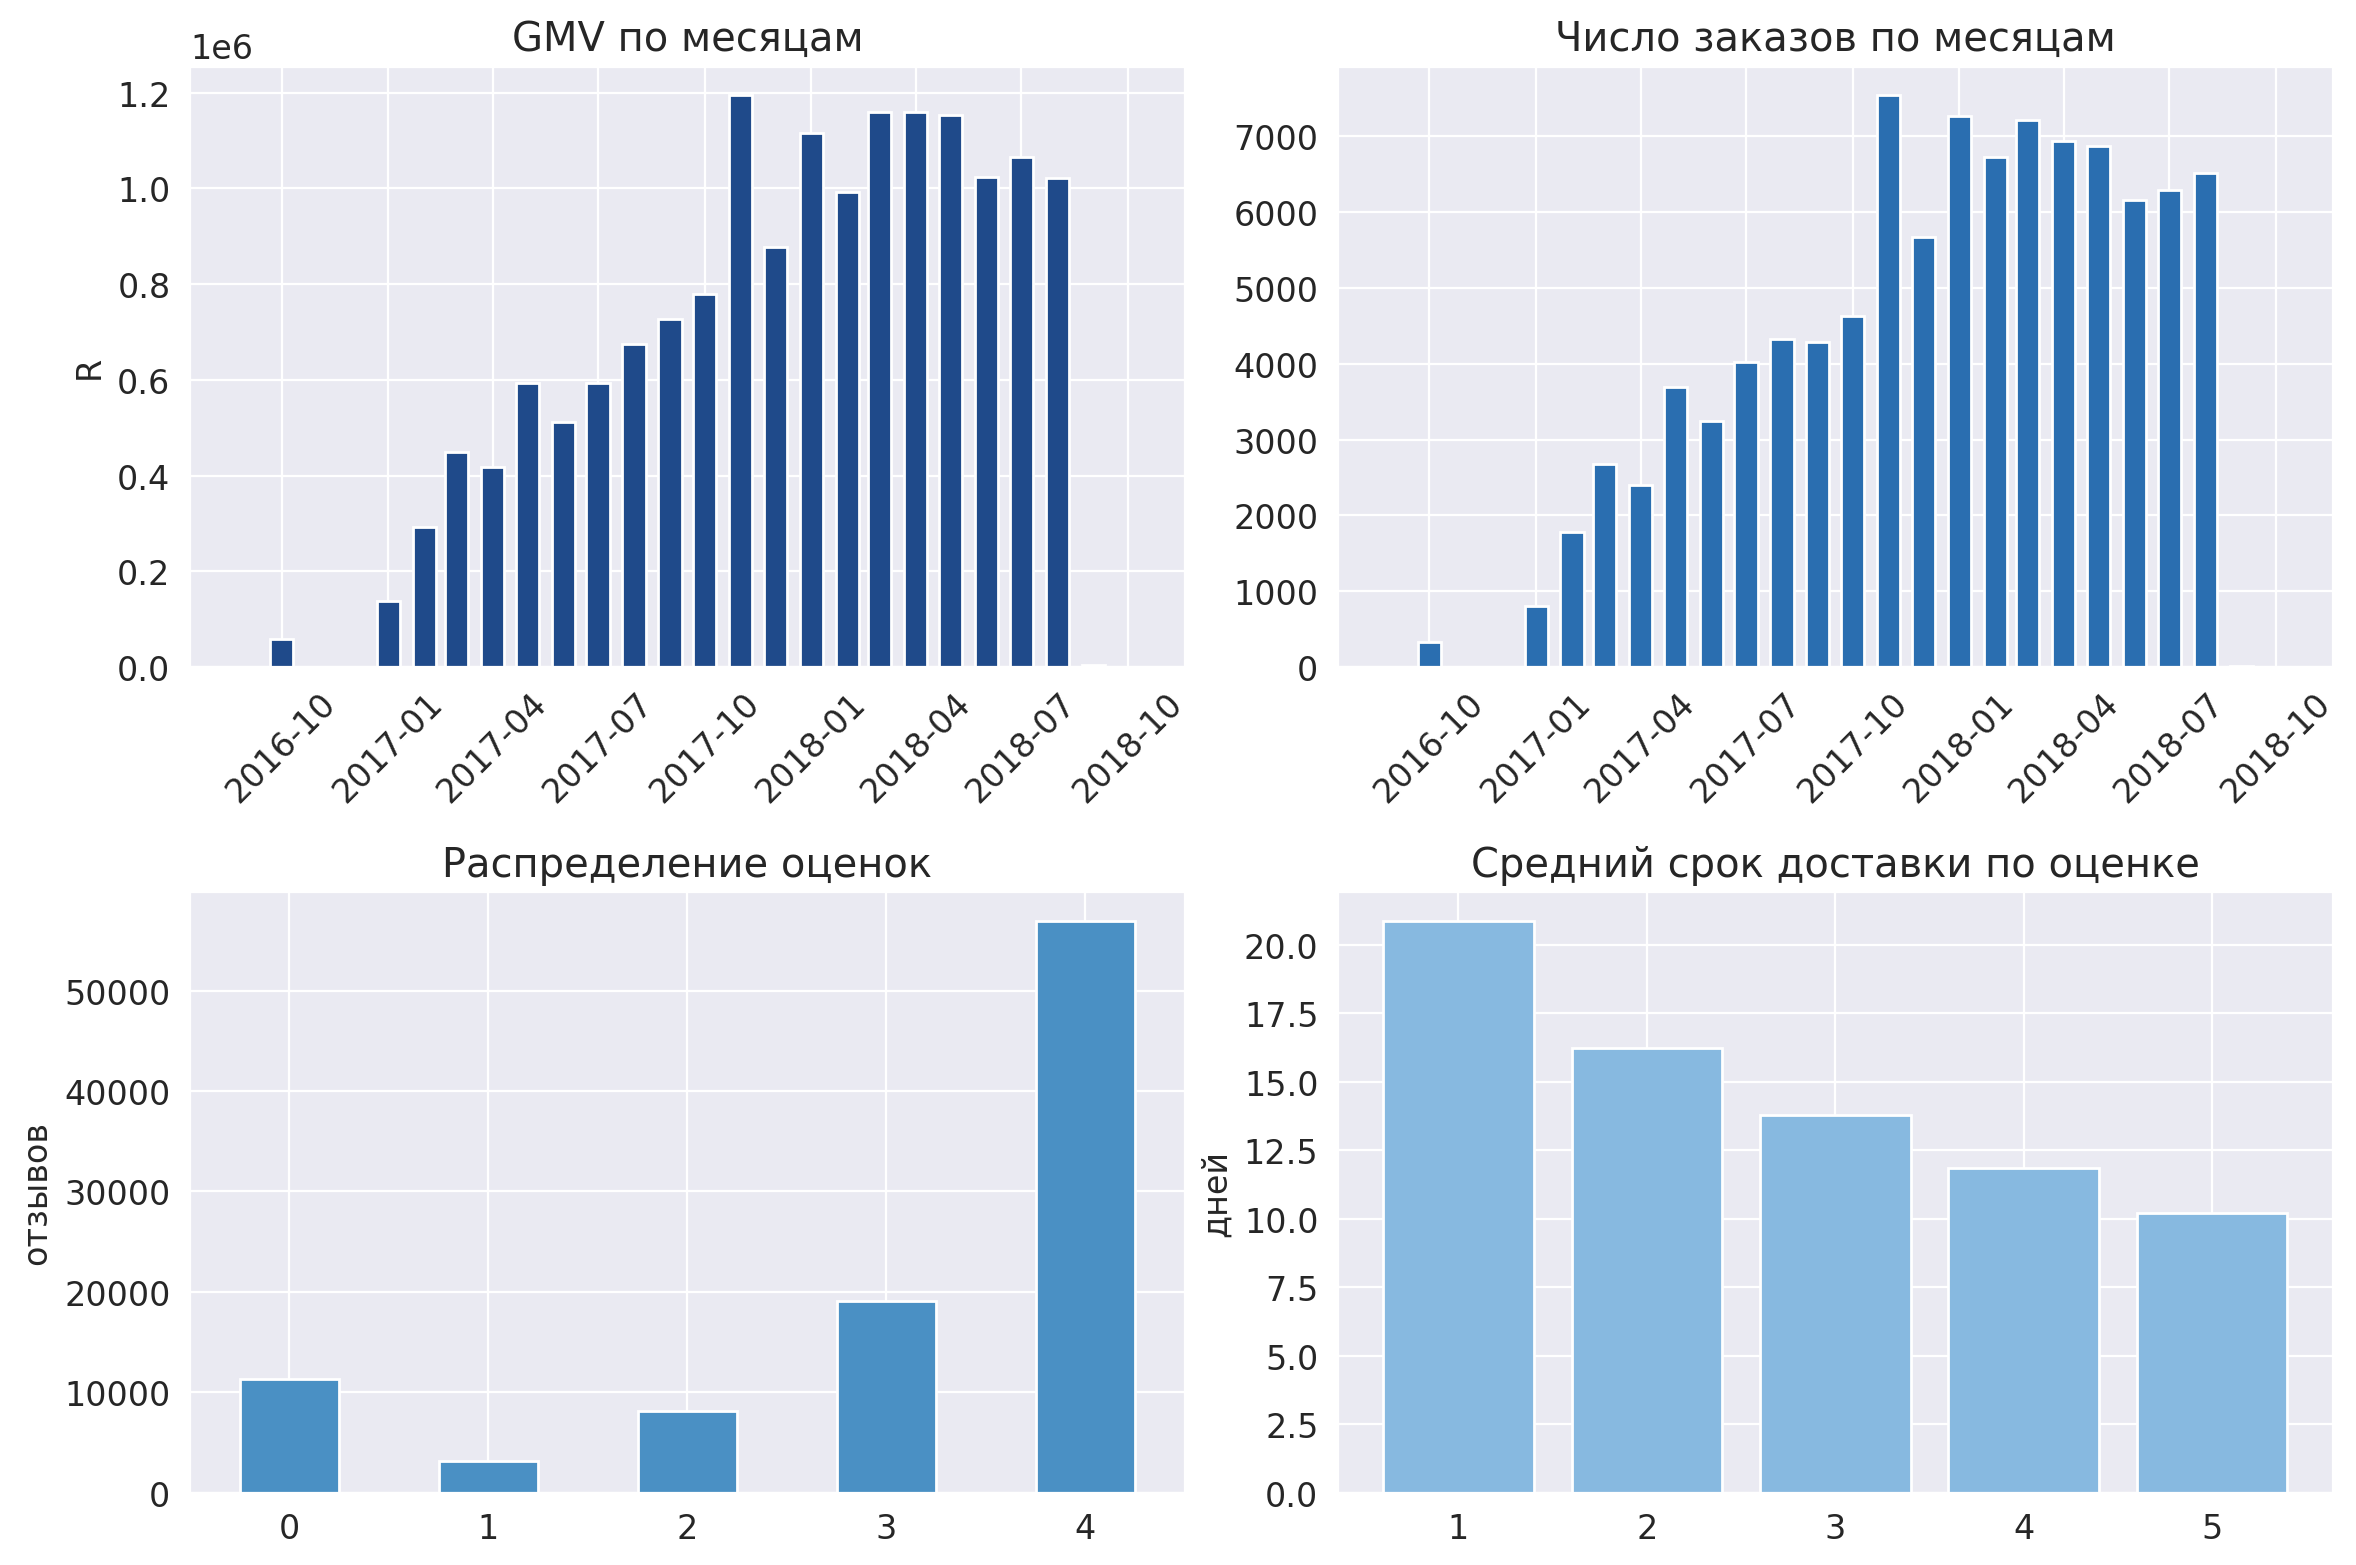

In [ ]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))
m = df.groupby('order_month').agg(gmv=('order_value','sum'), n=('order_id','count'))
ax[0,0].bar(m.index, m['gmv'], width=20, color='#1f4a8a')
ax[0,0].set_title('GMV по месяцам')
ax[0,0].tick_params(axis='x', rotation=45)
ax[0,0].set_ylabel('R')
ax[0,1].bar(m.index, m['n'], width=20, color='#2a6eb0')
ax[0,1].set_title('Число заказов по месяцам')
ax[0,1].tick_params(axis='x', rotation=45)
df['review_score'].value_counts().sort_index().plot.bar(ax=ax[1,0], color='#4a90c4')
ax[1,0].set_title('Распределение оценок')
ax[1,0].xaxis.set_major_formatter(plt.FormatStrFormatter('%d'))
ax[1,0].set_xlabel('')
ax[1,0].tick_params(axis='x', rotation=0)
ax[1,0].set_ylabel('отзывов')
by_score = df.dropna(subset=['delivery_days']).groupby('review_score')['delivery_days'].mean()
ax[1,1].bar(by_score.index, by_score.values, color='#87b9e0')
ax[1,1].set_title('Средний срок доставки по оценке')
ax[1,1].set_ylabel('дней')
plt.tight_layout()
plt.show()

In [ ]:
top_cat = df.groupby('product_category_name_english')['order_value'].sum().sort_values(ascending=False).head(10).reset_index()
top_cat.columns = ['категория', 'GMV(R)']
print('Топ-10 категорий по GMV:')
print(top_cat.to_string(index=False))
top_states = df['customer_state'].value_counts(normalize=True).head(5).round(3).reset_index()
top_states.columns = ['штат', 'доля']
top_states['доля'] = (top_states['доля'] * 100).round(2).astype(str) + '%'
print("\nТоп-штаты:")
print(top_states.to_string(index=False))
repeat_rate = (df.groupby('customer_unique_id')['order_id'].nunique() > 1).mean()
print(f"\nВернувшихся покупателей: {repeat_rate*100:.2f}%")

print(f"\nСредний чек покупки(AOV): {round(df['order_value'].mean(), 2)} R")
print(f"Медианный чек покупки: {round(df['order_value'].median(), 2)} R")
print(f"Максимальный чек покупки: {round(df['order_value'].max(), 2)} R")
print(f"Одно-позиционных заказов: {(df['items_per_order'] == 1).mean()*100:.2f}%")
print(f"Медианная доля доставки в чеке: {df['freight_ratio'].median()*100:.2f}%")

print(f"\nВовремя доставленных заказов: {df['on_time_flag'].mean()*100:.2f}%")
print('Средний срок доставки(дней):', round(df['delivery_days'].mean()),
      '| медиана', round(df['delivery_days'].median()),
      '| макс', round(df['delivery_days'].max()))

print(f"\nДоля отмен: {df['is_canceled'].mean()*100:.2f}%")

Топ-10 категорий по GMV:
            категория     GMV(R)
        health_beauty 1441928.29
        watches_gifts 1306950.74
       bed_bath_table 1243405.71
       sports_leisure 1156192.38
computers_accessories 1059211.93
      furniture_decor  899540.68
           housewares  777984.28
           cool_stuff  719874.30
                 auto  685756.37
         garden_tools  580581.82

Топ-штаты:
штат  доля
  SP 42.0%
  RJ 12.9%
  MG 11.7%
  RS  5.5%
  PR  5.1%

Вернувшихся покупателей: 3.12%

Средний чек покупки(AOV): 160.99 R
Медианный чек покупки: 105.29 R
Максимальный чек покупки: 13664.08 R
Одно-позиционных заказов: 89.36%
Медианная доля доставки в чеке: 18.33%

Вовремя доставленных заказов: 91.89%
Средний срок доставки(дней): 12 | медиана 10 | макс 209

Доля отмен: 1.24%


**Выводы по EDA:**
- **Рост экстенсивный.** GMV быстро растёт в течение 2017 и выходит на плато к 2018.
- **Вернувшихся покупателей всего 3.12%**. Удержание почти нулевое, бизнес растёт за счёт привлечения новых клиентов.
- **Оценка зависит от срока доставки.** Средний срок доставки монотонно растёт по мере падения оценки — просрочка напрямую роняет оценку. Вовремя доставленных заказов — 91.9%, средний срок доставки 12 дней (медиана 10), но тяжёлый хвост до 209 дней.
- **Низкий средний чек, одно-позиционные корзины.** AOV: среднее 161 R, медиана 105 R, большой правый хвост (макс 13 664 R). Заказы преимущественно из 1 позиции.
- **Неравномерный спрос по регионам.** SP 42%, RJ 13%, MG 12%.
- **Низкие отмены.** Доля отмен — 1.24%. Это удобная контр-метрика для платёжных гипотез.

**Точки роста:**
1) удержание (повышение долю вернувшихся покупателей с 3.12%)
2) срок доставки, точность ETA — драйвер оценок
3) повышение средний чек, проблема одно-позиционных корзин
4) распределение по регионам

## Дерево метрик

**North Star Metric: GMV.**

GMV:
- Число заказов:
```
  - новые покупатели
  - доля вернувшихся покупателей
```
- AOV
```
  - число позиций в заказе
  - средняя цена позиции
  - средняя цена доставки
```
- Качество сервиса:
```
  - средний срок доставки в днях
  - доля вовремя доставленных заказов
  - средняя оценка
  - доля отмен
```

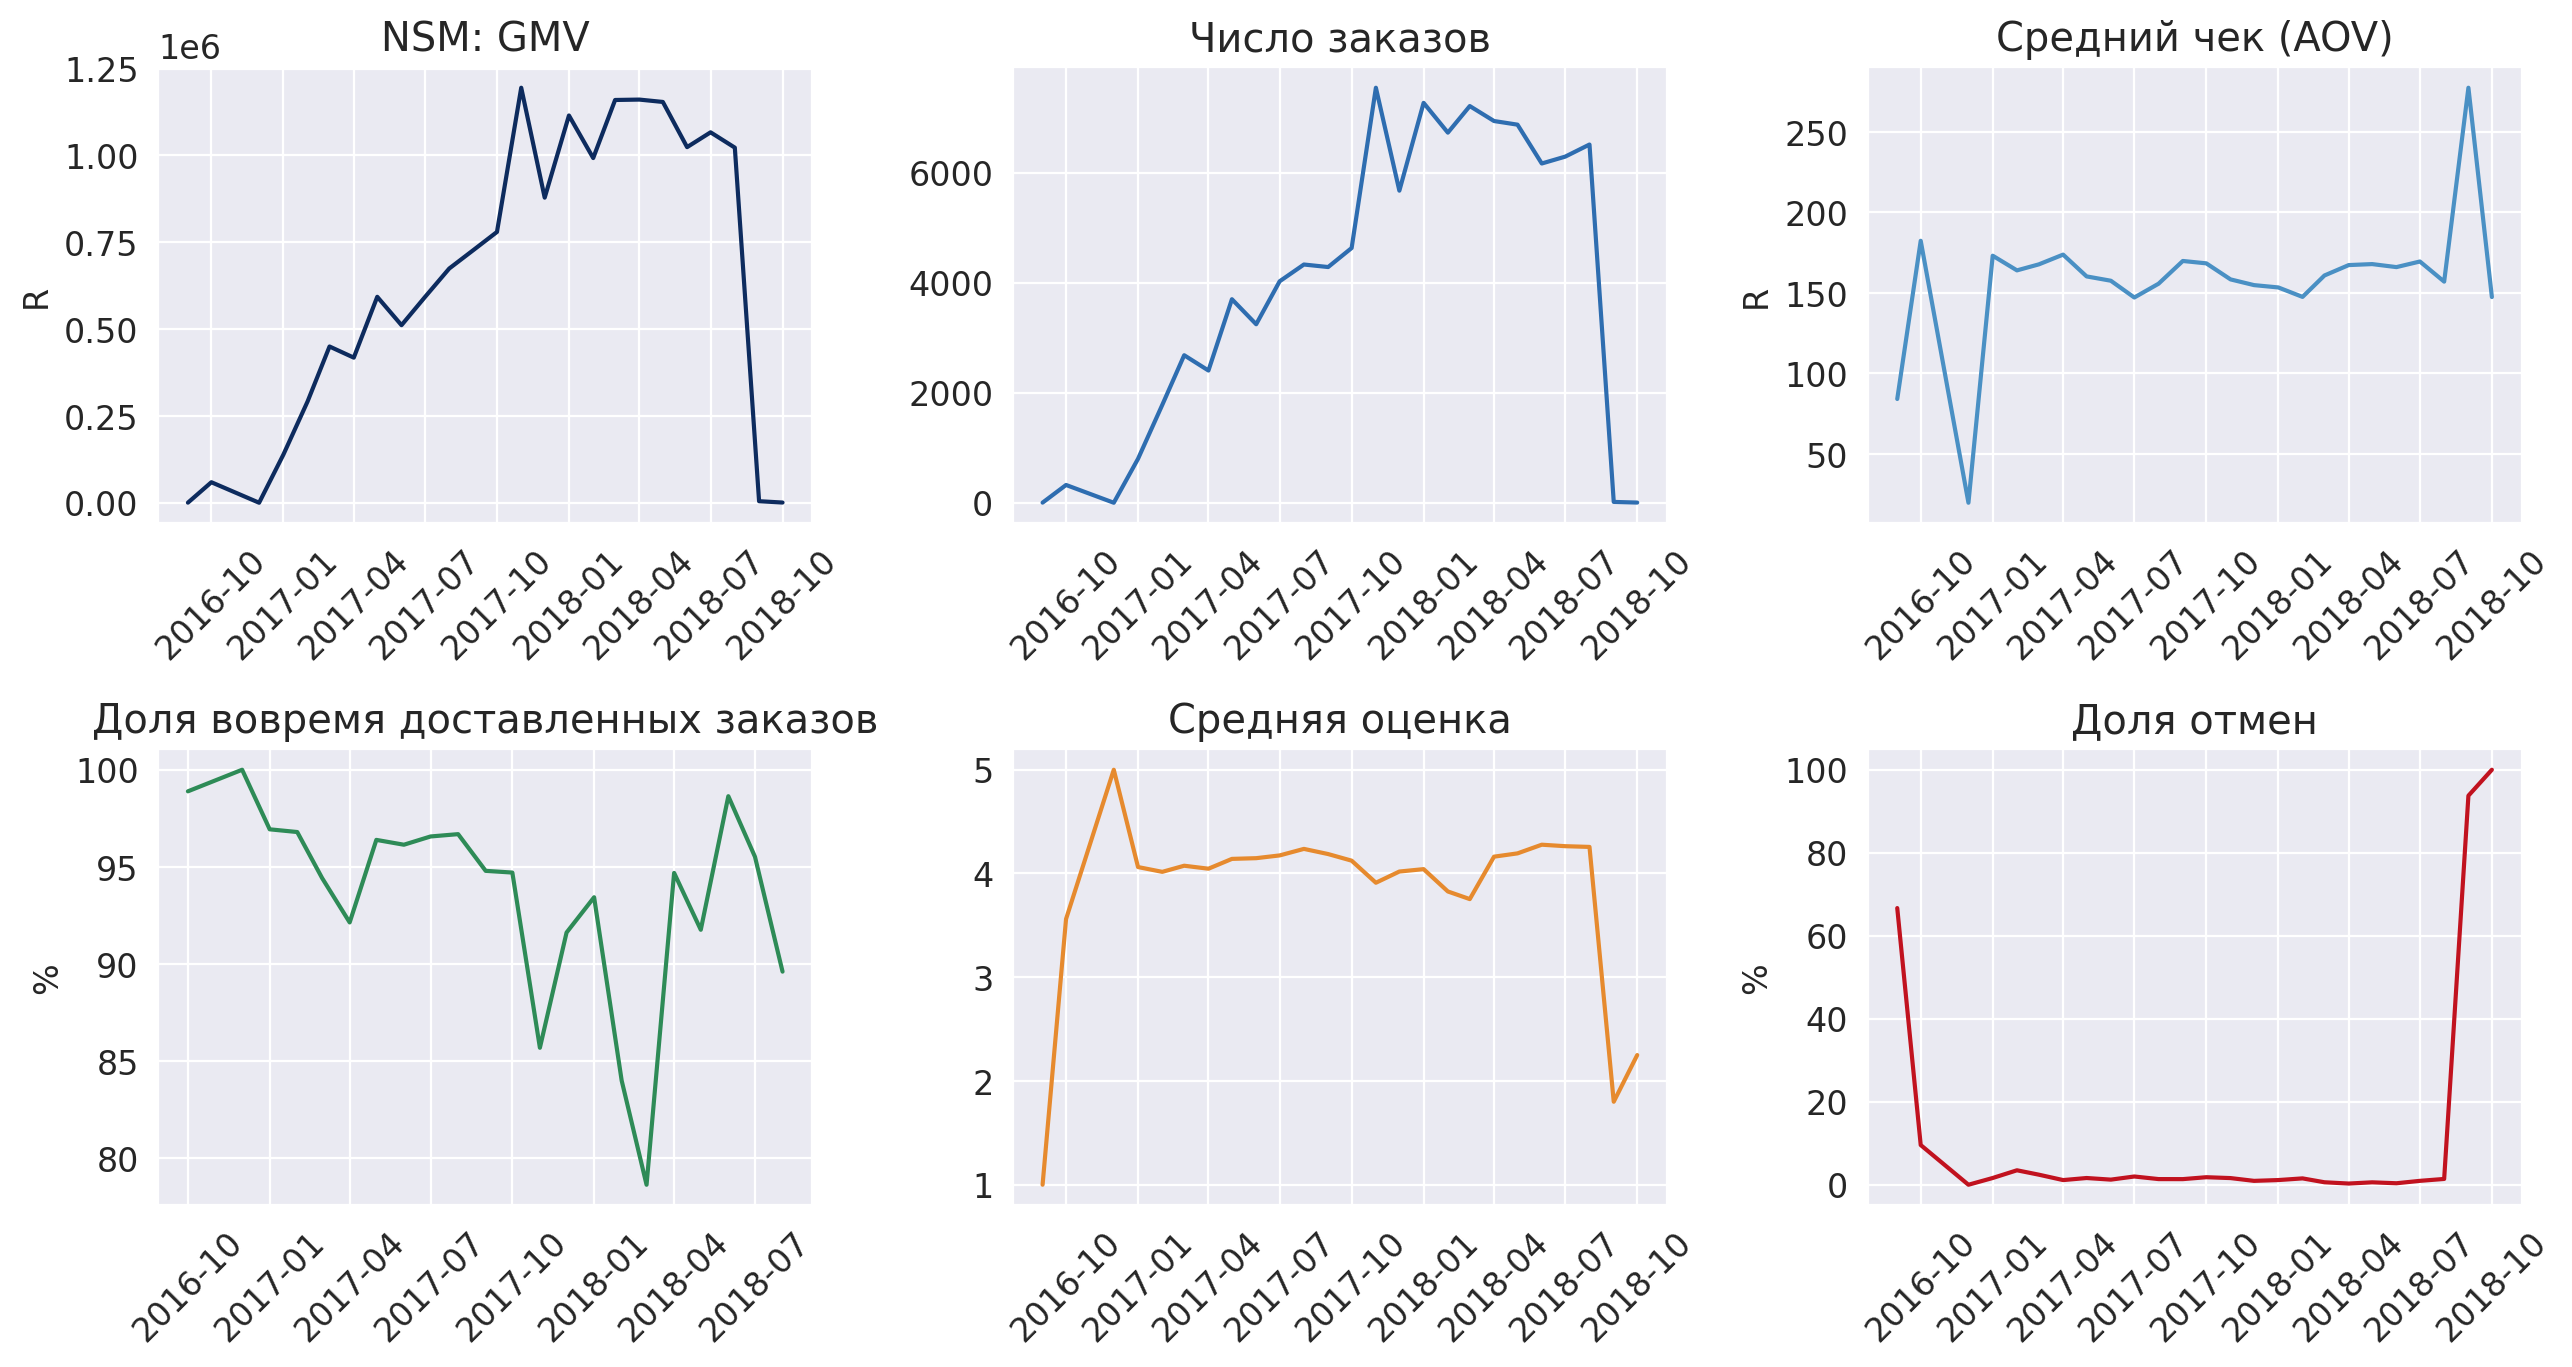

In [ ]:
gmv_df = df.dropna(subset=['order_value'])

m = gmv_df.groupby('order_month').agg(
        gmv=('order_value','sum'),
        n=('order_id','count'),
        aov=('order_value','mean'),
        on_time=('on_time_flag','mean'),
        review=('review_score','mean'),
        cancel=('is_canceled','mean'))
m['on_time'] = m['on_time'] * 100
m['cancel'] = m['cancel'] * 100

fig, ax = plt.subplots(2, 3, figsize=(13, 7))
plots_config = [
    ('gmv', 'NSM: GMV', '#0d2b5e', 'R', ''),
    ('n', 'Число заказов', '#2e6db0', '', ''),
    ('aov', 'Средний чек (AOV)', '#4a90c4', 'R', ''),
    ('on_time', 'Доля вовремя доставленных заказов', '#2e8b57', '%', ''),
    ('review', 'Средняя оценка', '#e68a2e', '', ''),
    ('cancel', 'Доля отмен', '#c1121f', '%', '')
]
for a, (col, ttl, clr, ylabel, fmt) in zip(ax.ravel(), plots_config):
    a.plot(m.index, m[col], color=clr)
    a.set_title(ttl)
    a.tick_params(axis='x', rotation=45)
    a.set_ylabel(ylabel)
plt.tight_layout()
plt.show()

assert np.allclose(m['gmv'], m['n']*m['aov']) #проверка GMV = число заказов × AOV

**Выводы по дереву метрик:**
- NSM: GMV.
- По графикам видно, что сейчас рост GMV определяется почти целиком числом заказов (притоком новых клиентов, так как доля возвращающихся — 3.12% не вносит сильного вклада); AOV почти плоская линия.
- Итог для гипотез: AOV и удержание почти не задействованы — над ними нужно работать.

## Гипотезы для A/B-тестов

Гипотезы опираются на EDA: низкий AOV и одно-позиционные корзины, связь времени доставки с отзывами, низкое удержание.

**Гипотеза 1. Беспроцентная рассрочка увеличит средний чек**\
Рассрочка до 6× без процентов на корзины $≥$ 105 R в крупнейших по обороту категориях.\
*Целевая:* AOV ↑ (ожидаемо +6%)\
*Контр:* доля отмен (не растёт)\
*Юнит:* клиент\
Обоснование: сейчас медианный чек всего 105 R и большинство корзин одно-позиционные. Рассрочка в Бразилии классически двигает покупку более дорогих товаров. Берём крупнейшие по обороту категории — там прирост чека даёт наибольший вклад в GMV.

**Гипотеза 2. Консервативный ETA увеличит среднюю оценку**\
Для продавцов с высокой просрочкой показывать срок доставки с запасом.\
*Целевая:* доля вовремя доставленных заказов ↑ (вторично средняя оценка ↑)\
*Контр:* число заказов на продавца (не должно упасть)\
*Юнит:* продавец\
Обоснование: доля вовремя доставленных заказов уже 91.9%, но именно просрочка сильно роняет оценки.

**Гипотеза 3. Бесплатная доставка начиная с определенной суммы увеличит средний чек**\
Бесплатаная доставка начиная с определенной суммы стимулирует достраивать корзину.\
*Целевая:* число позиций в заказе и AOV ↑\
*Контр:* число заказов\
*Юнит:* клиент

## Проработка гипотезы 1: ЦА, сплит-система, A/A тест, однородность, размер выборки

**Целевая аудитория и предэкспериментный период**

In [ ]:
target_cats = ['health_beauty', 'watches_gifts', 'bed_bath_table', 'sports_leisure', 'computers_accessories',
               'furniture_decor', 'housewares', 'cool_stuff', 'auto', 'garden_tools']
start = df['order_date'].max()
basket_min = 105
target = df[df['product_category_name_english'].isin(target_cats) & (df['order_value'] >= basket_min)].dropna(subset=['order_value']).copy()
pre = target[target['order_date'] < start].copy()
print('Старт теста:', start.date())
print('Заказов в целевой аудитории до старта эксперимента:', len(pre))

Старт теста: 2018-10-17
Заказов в целевой аудитории до старта эксперимента: 32317


**Сплит-система**

In [ ]:
def ab_split(id, salt):
  test_id = str(id) + "-" + str(salt)
  test_id_digest = hashlib.md5(test_id.encode("ascii")).hexdigest()
  if int(test_id_digest[-1], 16) % 2 == 0:
    return 'test'
  else:
    return 'control'

pre['group'] = pre['customer_unique_id'].apply(lambda u: ab_split(u, 'SALT1'))
print(pre['group'].value_counts().to_string())

group
test       16207
control    16110


**A/A тест (валидация сплит-системы)**

  0%|          | 0/10000 [00:00<?, ?it/s]

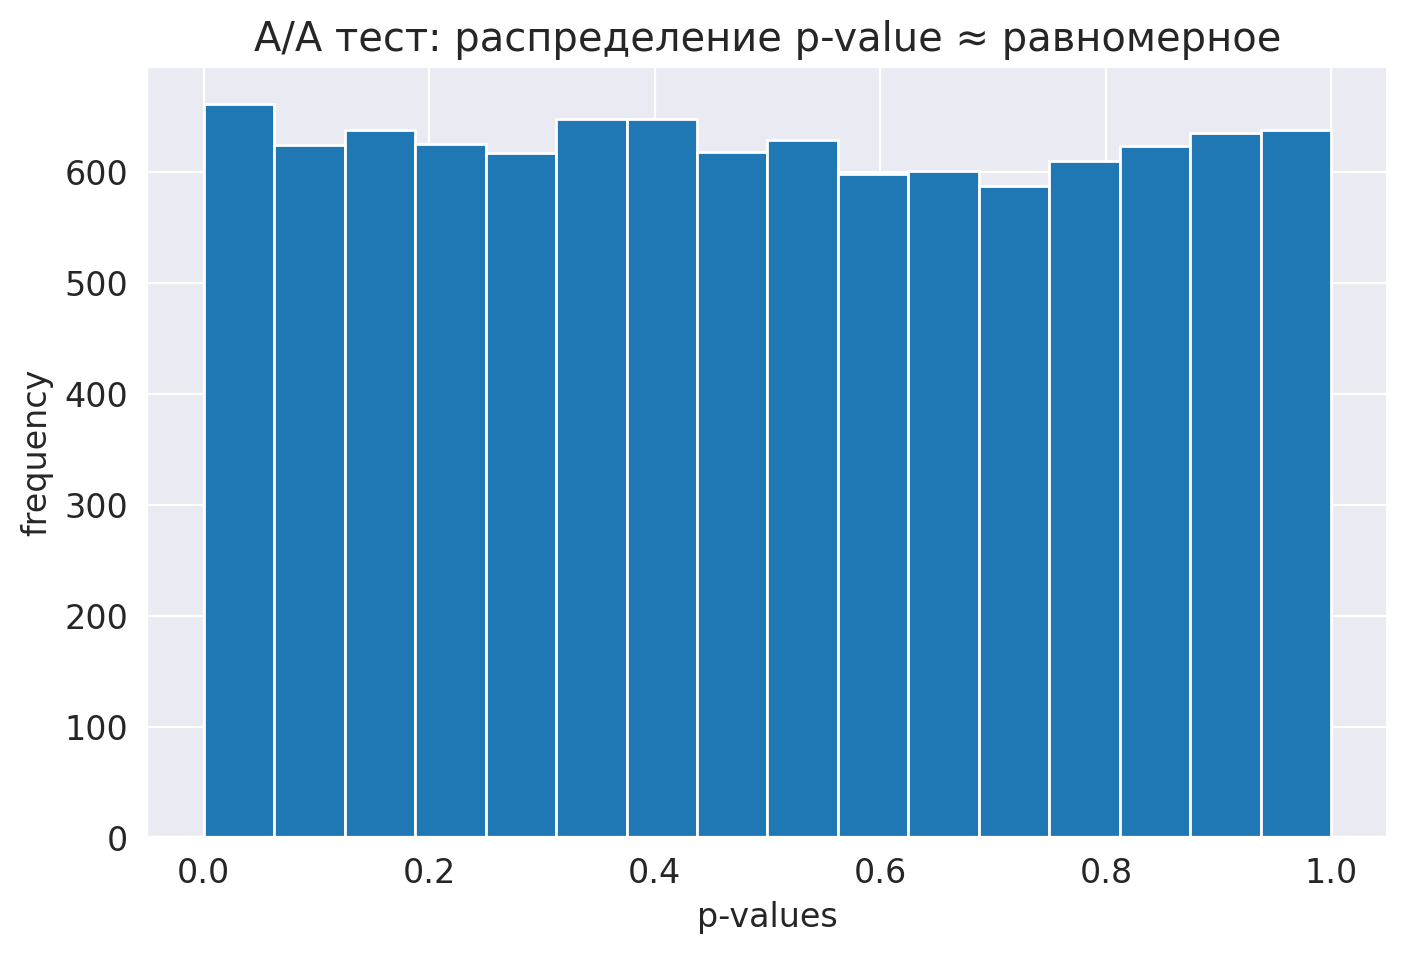

Ошибка I рода: 5.24% (ожидаем ~5%)


In [ ]:
codes, uniq = pd.factorize(pre['customer_unique_id'])
aov = pre['order_value'].to_numpy()
pvals = []
for _ in tqdm(range(10000)):
    g = rng.integers(0, 2, size=len(uniq))[codes]
    pvals.append(stats.ttest_ind(aov[g==0], aov[g==1], equal_var=False).pvalue)
pvals = np.array(pvals)

plt.hist(pvals, bins=16)
plt.title('A/A тест: распределение p-value ≈ равномерное')
plt.xlabel('p-values')
plt.ylabel("frequency")
plt.show()
print(f"Ошибка I рода: {(pvals<0.05).mean()*100:.2f}% (ожидаем ~5%)")

**Проверка однородности групп (3 характеристики)**

In [ ]:
print('Доли топ-5 штатов по группам:')
pd.crosstab(pre['customer_state'], pre['group'], normalize='columns').head(5).round(3)

Доли топ-5 штатов по группам:


group,control,test
customer_state,,
AC,0.001,0.001
AL,0.006,0.006
AM,0.001,0.002
AP,0.001,0.001
BA,0.036,0.038


In [ ]:
print('AOV по группам:')
pre.groupby('group')['order_value'].agg(['mean','std','count']).round(2)

AOV по группам:


,mean,std,count
group,,,
control,248.06,241.65,16110
test,246.44,246.29,16207


In [ ]:
print('Тип оплаты по группам:')
pd.crosstab(pre['payment_type'], pre['group'], normalize='columns').round(3)

Тип оплаты по группам:


group,control,test
payment_type,,
boleto,0.181,0.178
credit_card,0.785,0.787
debit_card,0.012,0.013
voucher,0.022,0.022


**Размер выборки и длительность**

Калькулятор mindbox устроен под конверсию/доли. Наша целевая метрика — AOV (среднее), а не доля. Для среднего калькулятор не подходит, поэтому применяем формулу.\
Контр-метрику (долю отмен) проверяем на той же выборке, что и целевую.

In [ ]:
z_sum = stats.norm.ppf(1-alpha/2) - stats.norm.ppf(1-power)
s = pre['order_value'].std()
aov_base = pre['order_value'].mean()
mde = 0.06 #минимально интересный эффект
delta = aov_base * mde #минимально интересный эффект в абсолютном значении
n_per_group = int(np.ceil(2 * z_sum**2 * s**2 / delta**2))
n_total = 2*n_per_group
DAU = pre.groupby('order_date').size().mean() #средний дневной поток заказов в ЦА
duration_days = int(np.ceil(n_total / DAU)) #длительность в днях
print(f"Размер группы: {n_per_group}")
print(f"Размер всей выборки: {n_total}")
print(f"Поток ЦА: {DAU:.0f} заказов в день")
print(f"Длительность: {duration_days} дней")

Размер группы: 4247
Размер всей выборки: 8494
Поток ЦА: 53 заказов в день
Длительность: 161 дней


**Выводы по дизайну теста:**
- **Целевая аудитория:** 10 крупнейших по GMV категорий, корзины $≥$ 105 R. До старта эксперимента в ЦА 32317 заказов. Сплит по клиенту сбалансирован (test: 16207, control: 16110).
- **A/A-тест:** ошибка I рода 5.24% ≈ α=5% → сплит-система корректна, группы сопоставимы (гистограмма p-value ≈ равномерная).
- **Однородность:** распределение по штатам, AOV и типам оплаты схожи → группы однородны минимум по трем характеристикам.
- **Размер выборки**: при MDE +6% → 4247 заказов на группу (8494 всего). При потоке ЦА ≈ 53 заказа в день длительность ≈ 161 день.

## Продолжение временного ряда

In [ ]:
#заказы за последние 90 дней предэкспериментного периода. Это историческое распределение метрики, из которого будем сэмплировать
aov_pool = pre[pre['order_date'] >= pre['order_date'].max() - pd.Timedelta(days=90)]['order_value'].to_numpy()

#историческая доля отмен (для контр-метрики)
cancel_base = pre['is_canceled'].mean()

#сколько наблюдений генерировать в день на одну группу
daily_per_group = int(np.ceil(n_per_group / duration_days))

rows = []
for d in range(duration_days):
    day = start + pd.Timedelta(days=d)
    for group, mult, cmult in [('control', 1.0, 1.0), ('test', 1.06, 1.02)]:
        rows.append(pd.DataFrame(dict(order_date=day, group=group,
            order_value=rng.choice(aov_pool, daily_per_group)*mult,
            is_canceled=(rng.random(daily_per_group) < cancel_base*cmult).astype(int))))
sim = pd.concat(rows, ignore_index=True)
print(f'Симулировано: {len(sim)} | на группу: {len(sim)//2} (плановый размер группы: {n_per_group})')

Симулировано: 8694 | на группу: 4347 (плановый размер группы: 4247)


## Итог A/B теста

In [ ]:
control = sim[sim.group=='control']['order_value'].to_numpy()
test = sim[sim.group=='test']['order_value'].to_numpy()

# целевая метрика: t-test, односторонняя H1: mu_t > mu_c (рассрочка только повышает чек, а не «как-то меняет»)
res = stats.ttest_ind(test, control, equal_var=False)
p = res.pvalue/2 if res.statistic > 0 else 1 - res.pvalue/2
crit = stats.norm.ppf(1-alpha) # большие выборки → t ≈ z
print("AOV(целевая метрика)")
print("H0: mu_test = mu_control\nH1: mu_test > mu_control")
print(f"Результат: mu_control = {control.mean():.2f}, mu_test = {test.mean():.2f} (Δ = {test.mean()-control.mean():+.2f} R)")
print(f"t-статистика = {res.statistic:.3f} | критическая статистика = {crit:.3f} | p-value = {p:.8f} →",
      "отвергаем H0" if p < alpha else "не отвергаем H0")

# контр-метрика: z-test для двух долей
cc = sim[sim.group=='control']['is_canceled']
tt = sim[sim.group=='test']['is_canceled']
z = (tt.mean()-cc.mean())/np.sqrt(cc.mean()*(1-cc.mean())/len(cc) + tt.mean()*(1-tt.mean())/len(tt))
p = 2*(1-stats.norm.cdf(abs(z)))
print(f"\nДоля отмен(контр-метрика)")
print(f"Результат: control = {cc.mean():.4f} test = {tt.mean():.4f}")
print(f"z-статистика = {z:.3f} | p-value = {p:.8f} →", "без значимого ухудшения" if p > alpha else "есть значимое изменение контр-метрики")

AOV(целевая метрика)
H0: mu_test = mu_control
H1: mu_test > mu_control
Результат: mu_control = 249.56, mu_test = 269.06 (Δ = +19.50 R)
t-статистика = 3.193 | критическая статистика = 1.645 | p-value = 0.00070542 → отвергаем H0

Доля отмен(контр-метрика)
Результат: control = 0.0044 test = 0.0046
z-статистика = 0.160 | p-value = 0.87249608 → без значимого ухудшения


In [ ]:
# бизнес-эффект: экстраполяция на год
days = (target['order_date'].max()-target['order_date'].min()).days
orders_year = len(target) * 365/days
print(f"Прирост AOV: {test.mean()-control.mean():+.2f} R на заказ\nЗаказов ЦА в год ≈ {orders_year:.0f}")
print(f"Годовой прирост GMV ЦА ≈ {(test.mean()-control.mean())*orders_year:.2f} R")

Прирост AOV: +19.50 R на заказ
Заказов ЦА в год ≈ 16292
Годовой прирост GMV ЦА ≈ 317647.34 R


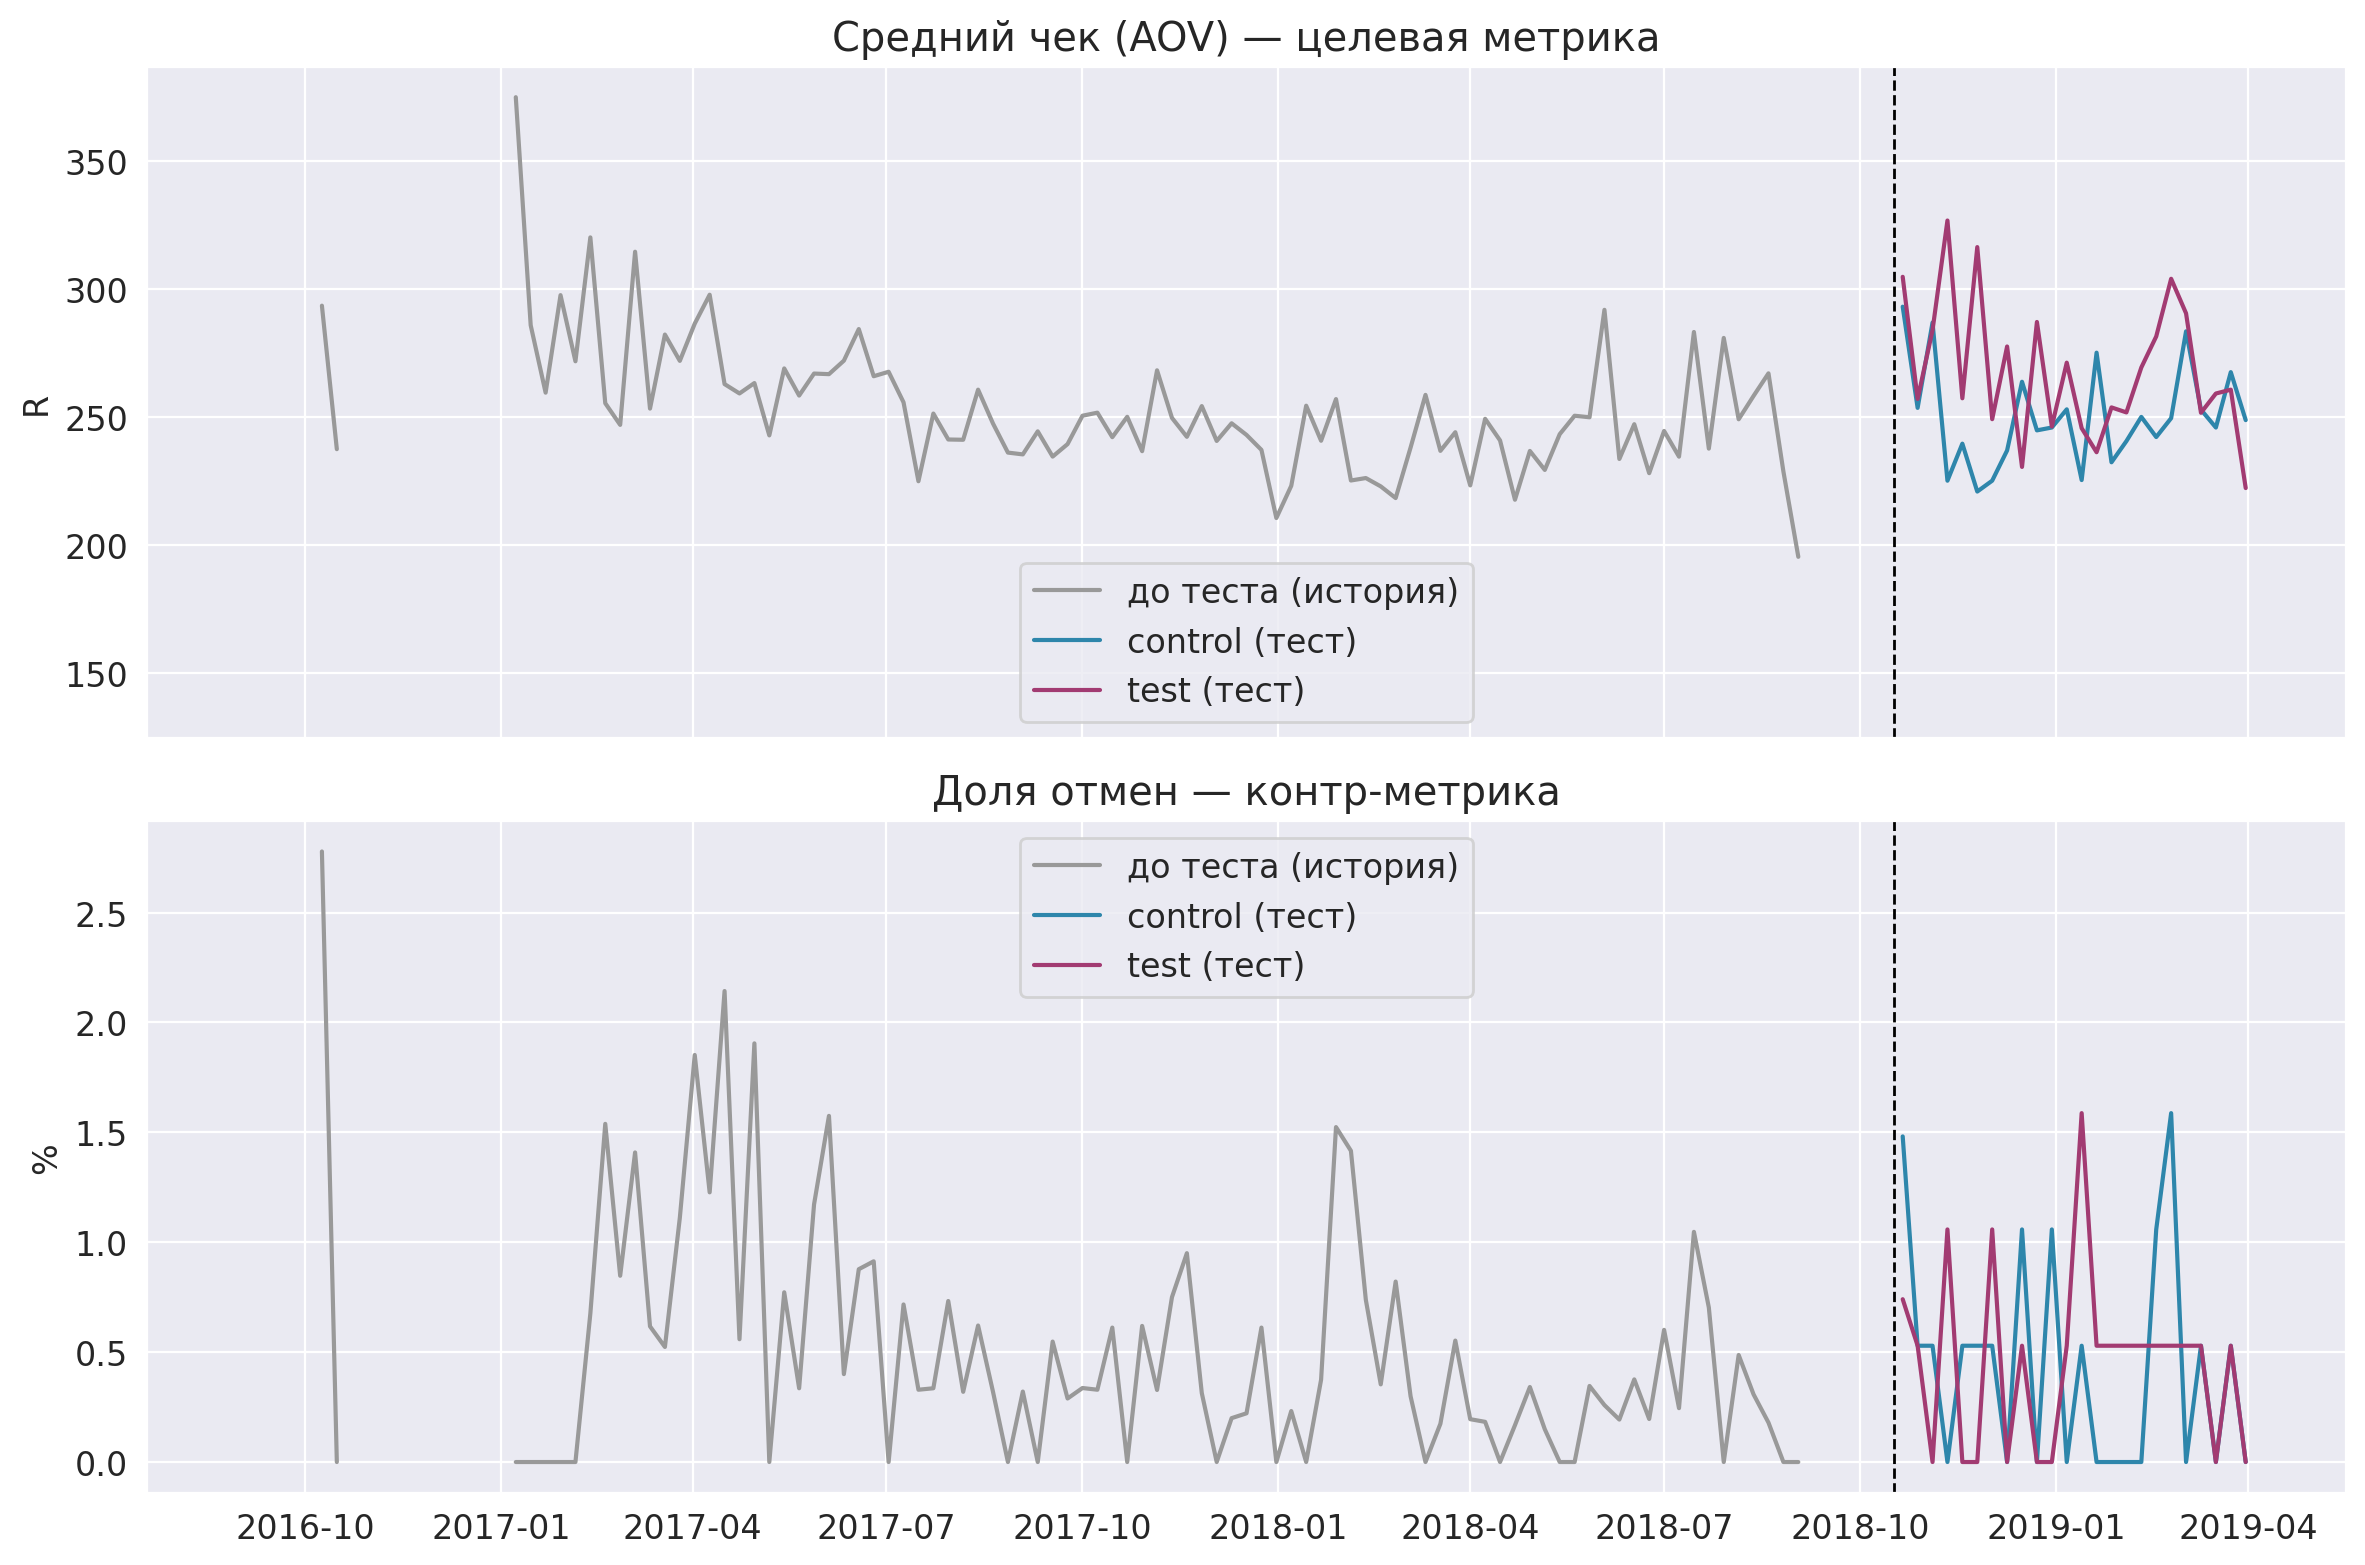

In [ ]:
pre_w = (pre.groupby(pd.Grouper(key='order_date', freq='W'))
            .agg(aov=('order_value', 'mean'), cancel=('is_canceled', 'mean')))
sim_w = (sim.groupby(['group', pd.Grouper(key='order_date', freq='W')])
            .agg(aov=('order_value', 'mean'), cancel=('is_canceled', 'mean'))
            .reset_index())

fig, ax = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
colors = {'control': '#2E86AB', 'test': '#A23B72'}

ax[0].plot(pre_w.index, pre_w['aov'], color='#999999', label='до теста (история)')
for g in ['control', 'test']:
    d = sim_w[sim_w['group'] == g]
    ax[0].plot(d['order_date'], d['aov'], color=colors[g], label=f'{g} (тест)')
ax[0].axvline(start, ls='--', color='black', lw=1)
ax[0].set_title('Средний чек (AOV) — целевая метрика')
ax[0].set_ylabel('R')
ax[0].legend()

ax[1].plot(pre_w.index, pre_w['cancel'] * 100, color='#999999', label='до теста (история)')
for g in ['control', 'test']:
    d = sim_w[sim_w['group'] == g]
    ax[1].plot(d['order_date'], d['cancel'] * 100, color=colors[g], label=f'{g} (тест)')
ax[1].axvline(start, ls='--', color='black', lw=1)
ax[1].set_title('Доля отмен — контр-метрика')
ax[1].set_ylabel('%')
ax[1].legend()

plt.tight_layout()
plt.show()

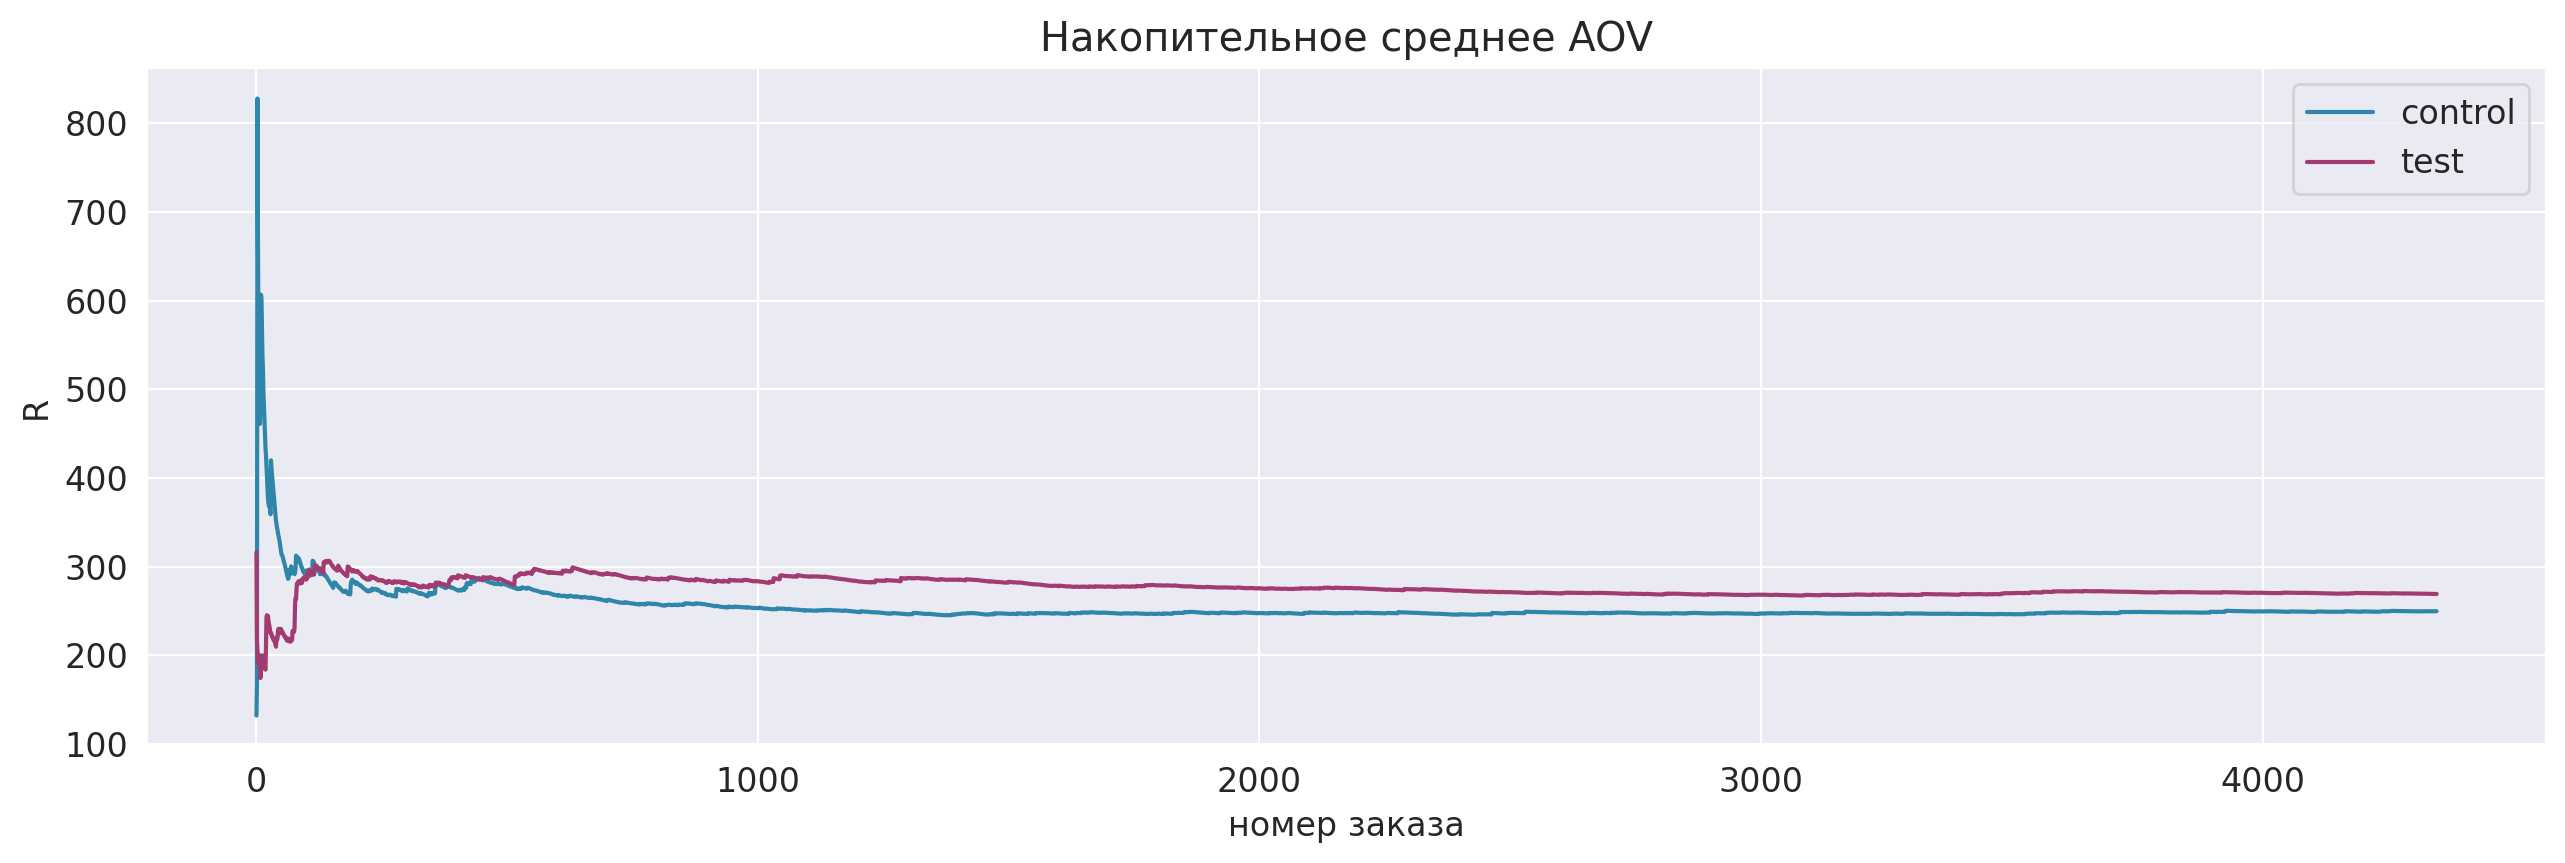

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(13, 4.5))
sim_sorted = sim.sort_values('order_date')

for g, clr in [('control','#2E86AB'), ('test','#A23B72')]:
    v = sim_sorted[sim_sorted.group == g]['order_value']
    ax.plot(np.arange(1, len(v)+1), v.expanding().mean().values, color=clr, label=g)

ax.set_title('Накопительное среднее AOV')
ax.set_xlabel('номер заказа')
ax.set_ylabel('R')
ax.legend()
plt.tight_layout()
plt.show()

**Выводы по итогам A/B-теста:**
- **Целевая метрика (AOV):** Тест выше контроля больше, чем на +6% (≈ +19.50 R на заказ), t-статистика = 3.193 > критической = 1.645, p-value < 0.05 → **H0 отвергаем, эффект значим**.
- **Контр-метрика (доля отмен):** Различие между группами незначимо (p > 0.05) → рассрочка **не ухудшает** отмены.
- **Бизнес-эффект:** Прирост ≈ +19.50 R на заказ при ≈ 16292 заказах ЦА в год → ≈ **+300 тыс. R GMV в год** по целевым категориям.
- **Совет бизнесу:** раскатывать беспроцентную рассрочку на корзины ≥ 105 R в крупнейших категориях — значимо повышает средний чек без роста отмен.

## Как переработать дизайн, если эффект не подтвердится

Если эффект окажется незначимым, можно:
- **Снизить дисперсию метрики.** AOV с тяжёлым хвостом (макс 13 664 при медиане 105) — можно обрезать верхний 1%, это уменьшит дисперсию, а значит, для обнаружения эффекта будет нужна меньшая выборка.
- **CUPED.** Ковариата = предэкспериментное значение метрики у того же юнита. У разовых клиентов истории почти нет (возвращаются только 3% клиентов) → эффективнее применить CUPED на уровне **продавца/региона**, где история есть.
- **Стратификация** по штату/категории товара и стратифицированная рандомизация. Это уменьшит дисперсию и повысит мощность теста.
- **Увеличить MDE или сузить ЦА** до сегмента с максимальным ожидаемым эффектом (например, только дорогие категории) — но это удлиняет срок из-за меньшего потока: надо искать компромисс между чувствительностью и длительностью.
- **Пересмотреть воздействие:** если рассрочка не двигает чек, возможно, стоит тестировать другую гипотезу.